# Exploration du dataset

## Description

Le dataset contient une sequence d'images d'une voiture en mouvement. La voiture est consideree comme un objet rigide: sa forme globale reste suffisamment stable pour que son centre puisse representer sa position dans le temps. L'ordre temporel des frames est essentiel, car l'estimation du mouvement repose sur les variations entre images successives. Cette etape sert donc a comprendre les donnees avant d'appliquer le pipeline de suivi.


Frames chargees: 1661
Bbox manuelle utilisee dans les notebooks: (535, 300, 220, 105)
Nombre total de frames: 1661
Dimensions des images: 1280 x 720
Premiere frame: 00000001.jpg
Derniere frame: 00001661.jpg


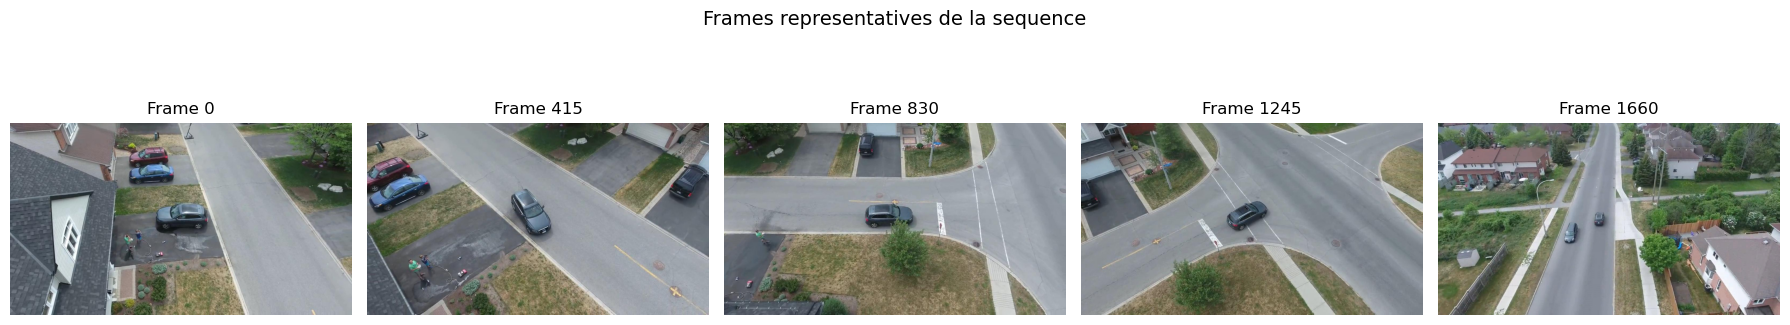

Figure sauvegardee: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\results\dataset_exploration\frames_representatives.png


In [ ]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / "data" / "car" / "car-11" / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted([p for p in DATASET_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}])
if not image_files:
    raise RuntimeError("Aucune image trouvee dans data/car/car-11/img/.")

initial_bbox = (535, 300, 220, 105)  # bbox manuelle: x, y, w, h

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_bgr(image, title, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr_to_rgb(image))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(image, title, figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_saved_image(path, title=None, figsize=(12, 6), is_gray=False):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE if is_gray else cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"Image illisible: {path}")
    if is_gray:
        show_gray(image, title or path.name, figsize=figsize)
    else:
        show_bgr(image, title or path.name, figsize=figsize)
    return image

def save_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def save_gray(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

print(f"Frames chargees: {len(image_files)}")
print(f"Bbox manuelle utilisee dans les notebooks: {initial_bbox}")

exploration_dir = ensure_dir(RESULTS_DIR / "dataset_exploration")
first_frame = cv2.imread(str(image_files[0]))
height, width = first_frame.shape[:2]
print("Nombre total de frames:", len(image_files))
print("Dimensions des images:", width, "x", height)
print("Premiere frame:", image_files[0].name)
print("Derniere frame:", image_files[-1].name)

indices = np.linspace(0, len(image_files) - 1, 5, dtype=int)
fig, axes = plt.subplots(1, len(indices), figsize=(18, 4))
for ax, idx in zip(axes, indices):
    frame = cv2.imread(str(image_files[idx]))
    ax.imshow(bgr_to_rgb(frame))
    ax.set_title(f"Frame {idx}")
    ax.axis("off")
fig.suptitle("Frames representatives de la sequence", fontsize=14)
fig.tight_layout()
grid_path = exploration_dir / "frames_representatives.png"
fig.savefig(grid_path, dpi=150)
plt.show()
print("Figure sauvegardee:", grid_path)


## Interpretation

La grille montre que la voiture est visible dans la scene et que son deplacement peut etre observe dans le temps. La sequence est adaptee a l'etude du mouvement d'un objet unique, car les frames sont ordonnees et le vehicule conserve une apparence globalement rigide. Les limites possibles viennent de l'eclairage, des ombres, des objets proches et de la taille apparente de la voiture.


## Resume de l'etape

Cette etape a permis de charger la sequence, de verifier le nombre de frames et leurs dimensions, puis d'observer quelques images representatives. Elle prepare les traitements suivants en confirmant que l'objet a suivre est visible et que l'ordre temporel peut etre exploite.
